<a href="https://colab.research.google.com/github/zeusandatlasgh/hw00zeusandatlas/blob/zeusandatlas/CPE486586_HigginbothamArwen_HW02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Arwen Higginbotham
agh0037@uah.edu

1) No. A and B are not disjoint. P(B) = 1-1/4 = 3/4 and P(A) = 1/3. For them to be disjoint, P(A n B) must equal zero. Here, P(A u B) = P(A) + P(B) = 3/4+1/3 = 13/12. This is more than one and it can't be greater than one to be disjoint.

2.

F_X(2.5) = 0.875 (0.875)


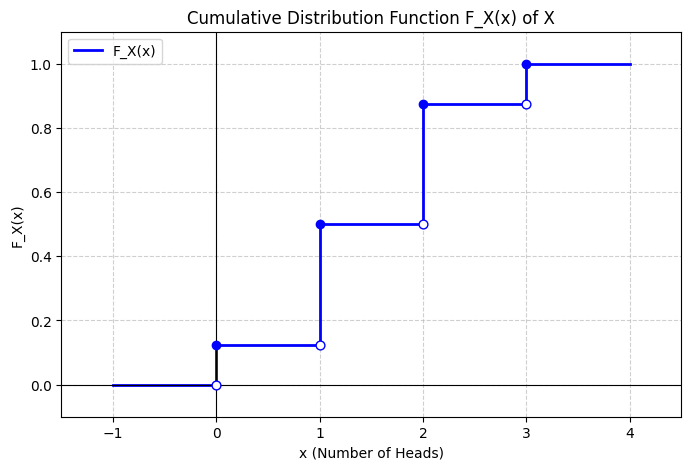

In [8]:
# Number 5
import numpy as np
import matplotlib.pyplot as plt
def cdf_X(x):
    if x < 0:
        return 0.0
    elif 0 <= x < 1:
        return 1/8
    elif 1 <= x < 2:
        return 1/2
    elif 2 <= x < 3:
        return 7/8
    else:
        return 1.0
val_2_5 = cdf_X(2.5)
print(f"F_X(2.5) = {val_2_5} ({val_2_5:.3f})")
x = [-1, 0, 1, 2, 3, 4]
y = [0, 1/8, 1/2, 7/8, 1, 1]
plt.figure(figsize=(8, 5))
plt.step(x, y, where='post', color='blue', linewidth=2, label='F_X(x)')
intervals = [0, 1, 2, 3]
heights = [1/8, 1/2, 7/8, 1]
previous_heights = [0, 1/8, 1/2, 7/8]
plt.scatter(intervals, heights, color='blue', zorder=3)
plt.scatter(intervals, previous_heights, color='white', edgecolor='blue', s=40, zorder=3)
plt.title('Cumulative Distribution Function F_X(x) of X')
plt.xlabel('x (Number of Heads)')
plt.ylabel('F_X(x)')
plt.xlim(-1.5, 4.5)
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black',linewidth=0.8)
plt.axvline(0, color='black',linewidth=0.8)
plt.legend()
plt.show()

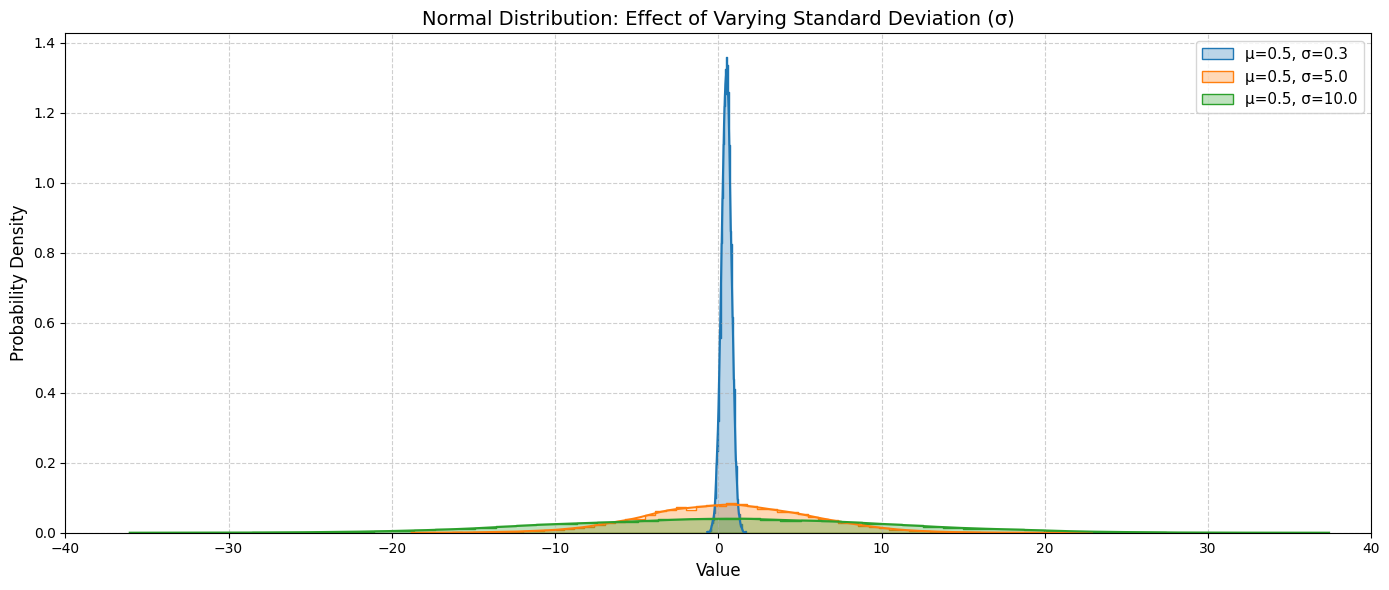

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
num_samples = 10000
mu = 0.5
sigma_values = [0.3, 5.0, 10.0]
plt.figure(figsize=(14, 6))
for sigma in sigma_values:
    samples = np.random.normal(loc=mu, scale=sigma, size=num_samples)

    sns.histplot(samples, kde=True, stat="density", element="step",
                 alpha=0.3, label=f'μ={mu}, σ={sigma}')
plt.title('Normal Distribution: Effect of Varying Standard Deviation (σ)', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(-40, 40)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

shape: (5, 6)
┌───────┬─────────────────────┬─────────┬───────────────┬──────┬──────────────┐
│ fk_id ┆ date                ┆ speed   ┆ speed_std_dev ┆ flow ┆ used_lanes   │
│ ---   ┆ ---                 ┆ ---     ┆ ---           ┆ ---  ┆ ---          │
│ i64   ┆ str                 ┆ f64     ┆ f64           ┆ i64  ┆ str          │
╞═══════╪═════════════════════╪═════════╪═══════════════╪══════╪══════════════╡
│ 1159  ┆ 2018-10-01 00:00:00 ┆ 26.6028 ┆ 7.1894        ┆ 165  ┆ {1,1,1,1}    │
│ 1159  ┆ 2018-10-01 00:01:00 ┆ 26.06   ┆ 4.10961       ┆ 160  ┆ {1,1,1,NULL} │
│ 1159  ┆ 2018-10-01 00:02:00 ┆ 25.0705 ┆ 9.05539       ┆ 105  ┆ {1,1,1,1}    │
│ 1159  ┆ 2018-10-01 00:03:00 ┆ 27.2009 ┆ 4.54606       ┆ 220  ┆ {1,1,1,NULL} │
│ 1159  ┆ 2018-10-01 00:04:00 ┆ 24.96   ┆ 7.93025       ┆ 180  ┆ {1,1,1,NULL} │
└───────┴─────────────────────┴─────────┴───────────────┴──────┴──────────────┘
Number of columns: 6
Column names: ['fk_id', 'date', 'speed', 'speed_std_dev', 'flow', 'used_lanes']
shape

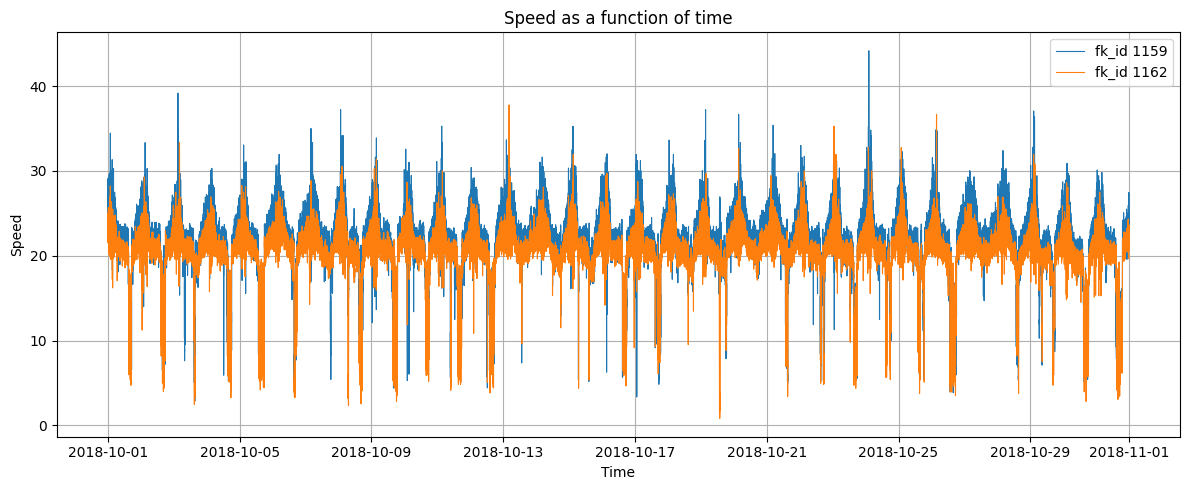

In [5]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
URL = "https://raw.githubusercontent.com/rahulbhadani/Datasets/master/mcsOct2018.csv"
df = pl.read_csv(URL)
print(df.head())
print("Number of columns:", df.width)
print("Column names:", df.columns)
df = (
    df.with_columns(
        pl.col("date")
        .str.to_datetime("%Y-%m-%d %H:%M:%S", time_zone="UTC")
        .dt.epoch(time_unit="s")
        .alias("posix_time")
    )
    .sort("posix_time")
)
print(df.select("date", "posix_time").head())
total = df.height
counts = (
    df.group_by("fk_id")
    .agg(pl.len().alias("num_records"))
    .with_columns((pl.col("num_records") / total * 100).alias("percent_of_total"))
    .sort("fk_id")
)
print(counts)
df = df.with_columns(
    pl.col("used_lanes")
    .str.strip_chars("{}")
    .str.replace_all("NULL", str(np.nan))
    .str.split(",")
    .list.eval(pl.element().cast(pl.Float64))
    .alias("lanes")
)
df = df.with_columns(
    pl.col("lanes")
    .list.eval(pl.element().is_not_nan())
    .list.sum()
    .alias("num_lanes_used")
)
print(df.select("used_lanes", "lanes", "num_lanes_used").head())
df = df.with_columns(
    (pl.col("speed_std_dev") > 10).alias("high_std_dev"),
    (pl.col("flow") == 0).alias("zero_flow"),
).with_columns(
    (pl.col("high_std_dev") | pl.col("zero_flow")).alias("is_anomaly")
)
print("High std dev rows:", df["high_std_dev"].sum())
print("Zero flow rows:   ", df["zero_flow"].sum())
print("Anomalous rows:   ", df["is_anomaly"].sum())
plt.figure(figsize=(12, 5))
for (fk_id,), sub in df.group_by("fk_id", maintain_order=True):
    plt.plot(sub["date"].str.to_datetime("%Y-%m-%d %H:%M:%S"),
             sub["speed"], label=f"fk_id {fk_id}", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Speed")
plt.title("Speed as a function of time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Top 3 countries by overall EV sales: ['China', 'USA', 'Germany']


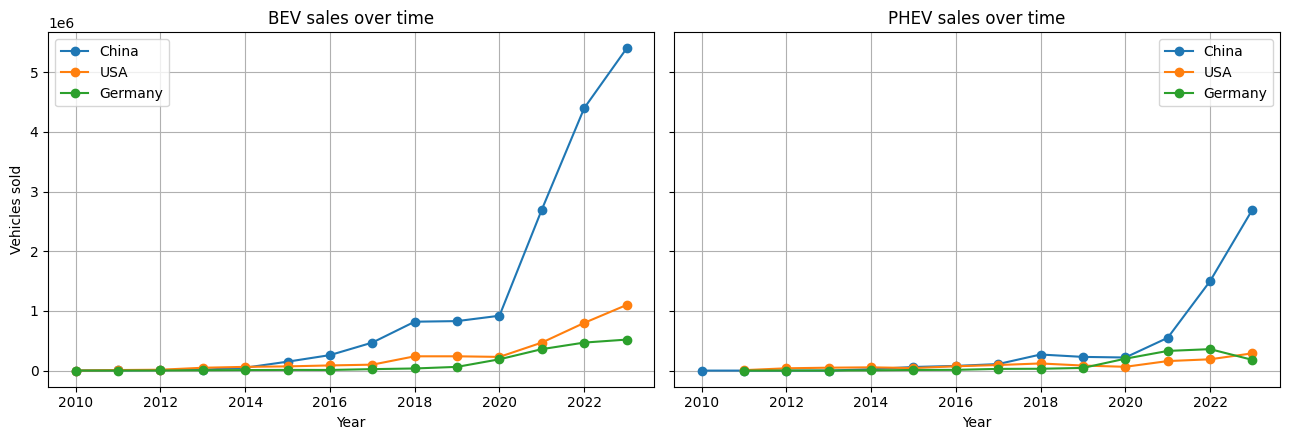

shape: (10, 5)
┌──────────────────────┬──────┬────────────┬───────────┬────────────────┐
│ region               ┆ year ┆ prev_sales ┆ bev_sales ┆ yoy_growth_pct │
│ ---                  ┆ ---  ┆ ---        ┆ ---       ┆ ---            │
│ str                  ┆ i64  ┆ f64        ┆ f64       ┆ f64            │
╞══════════════════════╪══════╪════════════╪═══════════╪════════════════╡
│ Israel               ┆ 2012 ┆ 3.0        ┆ 600.0     ┆ 19900.0        │
│ Sweden               ┆ 2011 ┆ 4.0        ┆ 180.0     ┆ 4400.0         │
│ Mexico               ┆ 2012 ┆ 3.0        ┆ 88.0      ┆ 2833.333333    │
│ Israel               ┆ 2017 ┆ 5.0        ┆ 130.0     ┆ 2500.0         │
│ United Arab Emirates ┆ 2020 ┆ 33.0       ┆ 630.0     ┆ 1809.090909    │
│ France               ┆ 2011 ┆ 190.0      ┆ 2600.0    ┆ 1268.421053    │
│ Bulgaria             ┆ 2017 ┆ 5.0        ┆ 68.0      ┆ 1260.0         │
│ Portugal             ┆ 2011 ┆ 13.0       ┆ 170.0     ┆ 1207.692308    │
│ Greece               

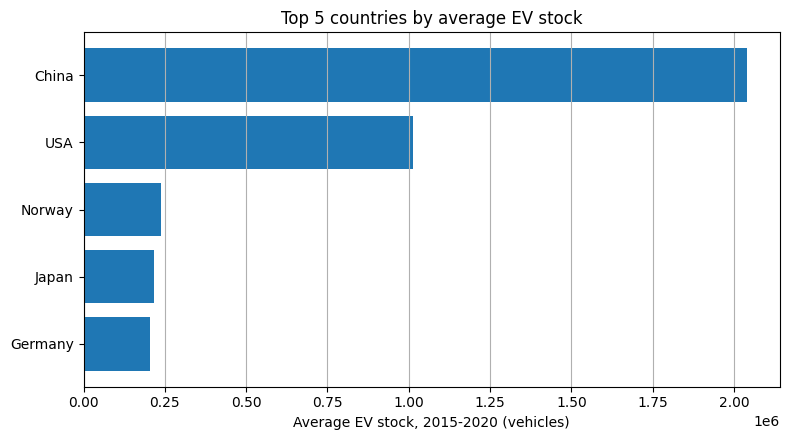

shape: (14, 3)
┌──────┬───────────┬────────────┐
│ year ┆ BEV_share ┆ PHEV_share │
│ ---  ┆ ---       ┆ ---        │
│ i64  ┆ f64       ┆ f64        │
╞══════╪═══════════╪════════════╡
│ 2010 ┆ 0.934767  ┆ 0.065233   │
│ 2011 ┆ 0.814589  ┆ 0.185411   │
│ 2012 ┆ 0.48311   ┆ 0.51689    │
│ 2013 ┆ 0.55548   ┆ 0.44452    │
│ 2014 ┆ 0.596203  ┆ 0.403797   │
│ …    ┆ …         ┆ …          │
│ 2019 ┆ 0.729173  ┆ 0.270827   │
│ 2020 ┆ 0.675742  ┆ 0.324258   │
│ 2021 ┆ 0.710836  ┆ 0.289164   │
│ 2022 ┆ 0.718517  ┆ 0.281483   │
│ 2023 ┆ 0.688652  ┆ 0.311348   │
└──────┴───────────┴────────────┘


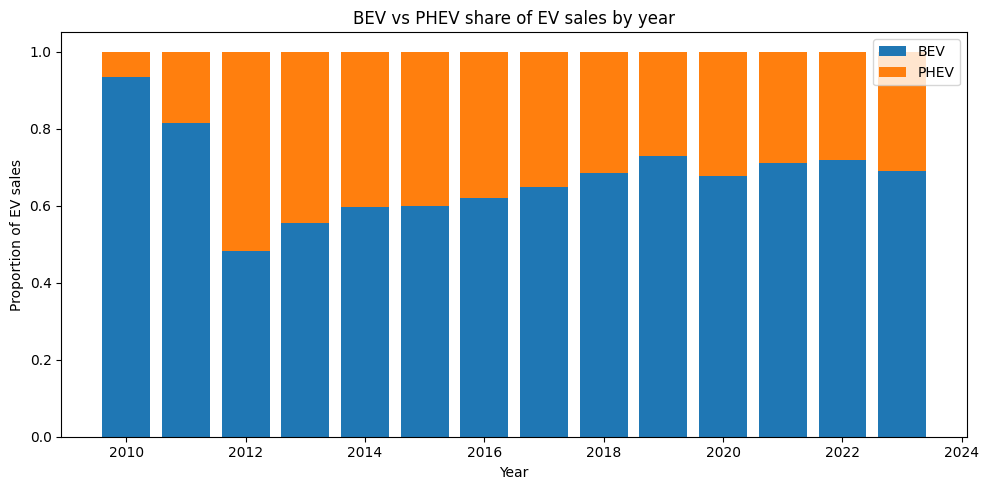

In [6]:
import polars as pl
import matplotlib.pyplot as plt
URL = ("https://raw.githubusercontent.com/rahulbhadani/Datasets/master/"
       "IEA-EV-dataEVsalesHistoricalCars.csv")
df = pl.read_csv(URL)
AGGREGATES = ["World", "Europe", "EU27", "Rest of the world"]
countries = df.filter(~pl.col("region").is_in(AGGREGATES))
sales = countries.filter(pl.col("parameter") == "EV sales")
top3 = (
    sales.group_by("region")
    .agg(pl.col("value").sum().alias("total_ev_sales"))
    .sort("total_ev_sales", descending=True)
    .head(3)["region"]
    .to_list()
)
print("Top 3 countries by overall EV sales:", top3)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, powertrain in zip(axes, ["BEV", "PHEV"]):
    for country in top3:
        sub = (sales.filter((pl.col("region") == country) &
                            (pl.col("powertrain") == powertrain))
                    .sort("year"))
        ax.plot(sub["year"], sub["value"], marker="o", label=country)
    ax.set_title(f"{powertrain} sales over time")
    ax.set_xlabel("Year")
    ax.grid(True)
    ax.legend()
axes[0].set_ylabel("Vehicles sold")
plt.tight_layout()
plt.show()
bev = (
    sales.filter(pl.col("powertrain") == "BEV")
    .select("region", "year", pl.col("value").alias("bev_sales"))
    .sort("region", "year")
    .with_columns(pl.col("bev_sales").shift(1).over("region").alias("prev_sales"))
    .filter(pl.col("prev_sales") > 0)
    .with_columns(
        ((pl.col("bev_sales") - pl.col("prev_sales")) / pl.col("prev_sales") * 100)
        .alias("yoy_growth_pct")
    )
    .sort("yoy_growth_pct", descending=True)
)
print(bev.select("region", "year", "prev_sales", "bev_sales", "yoy_growth_pct").head(10))
best = bev.row(0, named=True)
print(f"Highest growth: {best['region']} in {best['year']} "
      f"({best['yoy_growth_pct']:.1f}%)")
avg_stock = (
    countries.filter((pl.col("parameter") == "EV stock") &
                     pl.col("year").is_between(2015, 2020))
    .group_by("region", "year")
    .agg(pl.col("value").sum().alias("ev_stock"))
    .group_by("region")
    .agg(pl.col("ev_stock").mean().alias("avg_ev_stock"))
    .sort("avg_ev_stock", descending=True)
    .head(5)
)
print(avg_stock)
plt.figure(figsize=(8, 4.5))
plt.barh(avg_stock["region"][::-1], avg_stock["avg_ev_stock"][::-1])
plt.xlabel("Average EV stock, 2015-2020 (vehicles)")
plt.title("Top countries EV stock")
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()
yearly = (
    sales.filter(pl.col("powertrain").is_in(["BEV", "PHEV"]))
    .group_by("year", "powertrain")
    .agg(pl.col("value").sum())
    .pivot(on="powertrain", index="year", values="value")
    .sort("year")
    .with_columns((pl.col("BEV") + pl.col("PHEV")).alias("total"))
    .with_columns(
        (pl.col("BEV") / pl.col("total")).alias("BEV_share"),
        (pl.col("PHEV") / pl.col("total")).alias("PHEV_share"),
    )
)
print(yearly.select("year", "BEV_share", "PHEV_share"))
plt.figure(figsize=(10, 5))
plt.bar(yearly["year"], yearly["BEV_share"], label="BEV")
plt.bar(yearly["year"], yearly["PHEV_share"], bottom=yearly["BEV_share"], label="PHEV")
plt.xlabel("Year")
plt.ylabel("Proportion of EV sales")
plt.title("BEV vs PHEV share of EV sales by year")
plt.legend()
plt.tight_layout()
plt.show()